# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** Track A: Standard Analysis Project

**Group members:** 

- Victor Bjerggaard Thøstesen
- Nikolai Mose Sannerum  
- Frederik Hansen Baattrup  

**Dataset:** 

During the project we look at game statistics for Premier league matches since 2005. The datasets from 2003/2004 and 2004/2005 seasons are disregarded due to reading issues. 

Some features of the full data is beforehand merged into the file named "Master file.csv". This master file contains the features: "HomeTeam", "AwayTeam", "Full Time Result (FTR)", "Referee", "Full Time Home Goal (FTHG)", "Full Time Away Goal (FTAG)", "Home Shots (HS)", "Away Shots (AS)", "Home Shots On Target (HST)", "Away Shots On Target (AST)", "Home Fouls (HF)", "Away Fouls (AF)", "Home Corner (HC)", "Away Corner (AC)", "Home Yellow (HY)", "Away Yellow (Ay)", "Home Red (HR)", "Away Red (AR)", "Average Home Win Odds (AvgH)", "Average Draw Odds (AvgD)", "Average Away Win Odds (AvgA)", "Date" and "Season".

**Initial task description (Module 1 perspective):**

For the first part of the project we want to analyze our dataset using clustering. Our tentative analysis goal is to pick out a set of features from the dataset which can be meaningfully clustered and compared to a ground truth. First we apply unsupervised clustering to group football matches using in game statistics. The chosen features will be combined and transformed in order to reduce dimensions and make the matches more comparable. Outcome-related variables FTHG, FTAG, FTR, HTR and odds are excluded from clustering to prevent data leak and reserved for evaluation. After normalizing the numeric features, clustering algorithms are applied to identify match groupings. The FTR column serves as ground truth to assess alignment between clusters and actual outcomes (home win, away win, draw). Cluster evaluation metrics includes contingency tables and cluster purity measurements.


## 0. Reproducibility and Setup

In [22]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pyclustering.cluster.clique import clique, clique_visualizer
from tqdm import tqdm
from scipy.spatial.distance import cdist
from sklearn.cluster import DBSCAN, KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.13.3 (main, Apr  8 2025, 13:54:08) [Clang 16.0.0 (clang-1600.0.26.6)]


## 1. Dataset Description and Loading

### Dataset Overview

- Source: https://www.football-data.co.uk/englandm.php?fbclid=IwY2xjawQVBq9leHRuA2FlbQIxMABicmlkETBhSDJ4V01maU9aZVJ1dkNsc3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHr9Bnmq21fRPvCUMfkcBIu9edZEMLrEi-QTbB8sBlRDK8vETlRUAA3XgndZg_aem_OCN-0ddvAe0Fob_1GlxMdg

- Number of instances: 7860
- Number of features / entities: 23
- Missing values: No missing values after preprocessing. However when the seasons were combined we used only the average odds (provided by different websites for different seasons).


In [23]:


# --- Data Extraction Function ---
# Here define a function to extract the chosen relevant data features from the raw CSV files.
# This function will look for the average odds columns and handle cases where they might be missing.

def extract_data(df, filename):
    """
    Extracts average in game features and home/draw/away odds from CSV file.
    Prefers BbAvH/D/A, otherwise falls back to AvgH/D/A.
    Adds season column extracted from filename.

    parameters:
    df: DataFrame containing the raw data from the CSV file.
    filename: The name of the CSV file, used to extract the season information.

    return: A DataFrame with the extracted features and season information, or None if required columns are missing.

    """

    primary_cols = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                  'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "BbAvH", "BbAvD", "BbAvA", 'Date']
    fallback_cols = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                  'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "AvgH", "AvgD", "AvgA", 'Date']

    season = os.path.splitext(filename)[0]

    # Trying to find Betbrain columns first
    if all(col in df.columns for col in primary_cols):
        result = df[primary_cols].copy()
        result.columns = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                            'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                            'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "AvgH", "AvgD", "AvgA", 'Date']
        print(f'Found primary columns: BbAvH, BbAvD, BbAvA for {filename}')

    # Else trying to find fallback columns
    elif all(col in df.columns for col in fallback_cols):
        result = df[fallback_cols].copy()
        print(f'Using fallback columns: AvgH, AvgD, AvgA for {filename}')

    # If neither set of columns is found, print a warning and return None
    else:
        print(f"⚠ Warning: Required odds columns not found in {filename}")
        return None

    # Add season column
    result["Season"] = season
    
    return result



In [24]:
# --- User settings begin ---
data_folder = "Data" #Define the folder where the raw CSV files are located.
# --- User settings end ---

new_data = []

for file in os.listdir(data_folder):
    if file.endswith(".csv"):
        path = os.path.join(data_folder, file)
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"⚠ Error reading {file}: {e}")
            continue

        extracted = extract_data(df, file)

        if extracted is not None:
            new_data.append(extracted)

# Combine everything into one dataframe
final_df = pd.concat(new_data, ignore_index=True)

Found primary columns: BbAvH, BbAvD, BbAvA for 20072008premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20112012premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20132014premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20242025premierleague.csv
⚠ Error reading 20042005premierleague.csv: 'utf-8' codec can't decode byte 0xa0 in position 75614: invalid start byte
Using fallback columns: AvgH, AvgD, AvgA for 20202021premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20192020premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20082009premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20062007premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20152016premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20222023premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20102011premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20092010premierleague.csv
Found primary 

In [25]:
print(f"\n Final dataset:")
final_df = final_df.dropna(subset=["HomeTeam", "AwayTeam"]) # 2014/2015 season has a row of NaN that is removed here
final_df.head()
final_df


 Final dataset:


,HomeTeam,AwayTeam,FTR,Referee,FTHG,FTAG,HS,AS,HST,AST,...,AC,HY,AY,HR,AR,AvgH,AvgD,AvgA,Date,Season
0,Aston Villa,Liverpool,A,M Riley,1.0,2.0,10.0,17.0,6.0,7.0,...,2.0,4.0,2.0,0.0,0.0,3.67,3.23,1.95,11/08/07,20072008premierleague
1,Bolton,Newcastle,A,C Foy,1.0,3.0,13.0,7.0,9.0,5.0,...,3.0,1.0,1.0,0.0,0.0,2.41,3.18,2.80,11/08/07,20072008premierleague
2,Derby,Portsmouth,D,M Dean,2.0,2.0,12.0,12.0,5.0,6.0,...,6.0,1.0,2.0,0.0,0.0,2.85,3.19,2.38,11/08/07,20072008premierleague
3,Everton,Wigan,H,M Clattenburg,2.0,1.0,12.0,14.0,8.0,4.0,...,2.0,0.0,0.0,0.0,0.0,1.66,3.45,5.25,11/08/07,20072008premierleague
4,Middlesbrough,Blackburn,A,A Marriner,1.0,2.0,10.0,4.0,6.0,4.0,...,3.0,3.0,4.0,0.0,0.0,2.41,3.18,2.81,11/08/07,20072008premierleague
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7855,Hull,Man United,D,L Probert,0.0,0.0,16.0,7.0,6.0,1.0,...,1.0,2.0,2.0,0.0,1.0,3.14,3.55,2.21,24/05/15,20142015premierleague
7856,Leicester,QPR,H,M Oliver,5.0,1.0,22.0,18.0,7.0,2.0,...,6.0,0.0,0.0,0.0,0.0,1.56,4.21,5.71,24/05/15,20142015premierleague
7857,Man City,Southampton,H,C Foy,2.0,0.0,15.0,13.0,6.0,4.0,...,4.0,1.0,1.0,0.0,0.0,1.56,4.27,5.61,24/05/15,20142015premierleague
7858,Newcastle,West Ham,H,M Atkinson,2.0,0.0,17.0,4.0,4.0,1.0,...,3.0,2.0,1.0,0.0,0.0,1.77,3.84,4.42,24/05/15,20142015premierleague


In [26]:
def encode_results(results):
    """
    Endcoding of results
    1: HOME WIN, -1: AWAY WIN, 0: DRAW

    parameters:
    results (list of dicts): results to encode 

    returns:
    encoding (numpy array): encoded results
    """
    encoding = np.zeros(len(results)) # Initialize encoding array

    for i in range(len(results)):
        if results[i] == "H":
            encoding[i] = 1 # Home win
        elif results[i] == "A":
            encoding[i] = -1 # Away win
        else:
            encoding[i] = 0 # Draw
    return encoding
data = final_df.copy()
ground_truth = encode_results(data['FTR'])
print("Amount of home wins: ", np.sum(ground_truth == 1))
print("Amount of away wins: ", np.sum(ground_truth == -1))
print("Amount of draws: ", np.sum(ground_truth == 0))

Amount of home wins:  3586
Amount of away wins:  2368
Amount of draws:  1906


## Clustering (Part I)

### Exploratory data analysis

#### New Features and Normalization

To make matches more comparable, new features were engineered as the difference between home and away statistics. A positive value indicates that the home team has a higher value for the given metric.

The following features were constructed:


- Shot difference $(HS - AS)$
- Shots on target difference $(HST - AST)$
- Foul difference $(HF - AF)$
- Corner difference $(HC - AC)$
- Difference in average betting odds $(AvgH - AvgA)$


After feature engineering, the variables were **normalized using z-score normalization** to ensure comparable scales across features.

#### Data insights:
Finally, histograms of the normalized features were plotted to inspect their distributions. The following insights are observed: 
- All variables appear roughly symmetric and centered around zero, which is expected after z-score normalization. This indicates that, on average, neither the home nor away team consistently dominates these metrics across matches.

- most feature distributions appear approximately Gaussian after normalization. The exceptions are RC_diff and YC_diff, which are highly discrete due to the low and integer-valued nature of card events. The largely unimodal and continuous shape of the other features suggests that the data may not naturally separate into distinct groups across all variables. Any potential clustering structure may therefore rely more heavily on the discrete features.

Overall, this indicates that clusters, if present, are likely to be weakly separated, which may make clustering more challenging.

#### Scatter Plots:
The scatter plots below show the relationships between the normalized features and the ground truth, **Full Time Result (FTR)**, which indicates whether the home team won (1), drew (0), or lost (-1). Each scatter plot illustrates how various match statistics, such as shot differences, foul differences, and card differences, are distributed against FTR:

- **SD vs FTR**: Shot difference vs Full Time Result
- **SOTD vs FTR**: Shots on target difference vs Full Time Result
- **F_diff vs FTR**: Foul difference vs Full Time Result
- **C_diff vs FTR**: Corner difference vs Full Time Result
- **AvgOdds_diff vs FTR**: Difference in average betting odds vs Full Time Result

Each scatter plot demonstrates the relationship between these engineered features and FTR (ground truth). This was done to get an idea of which features that seems important when comparing to ground truth. It seems that there are some correlation between some of the features and ground truth, though they still might be hard to cluster.

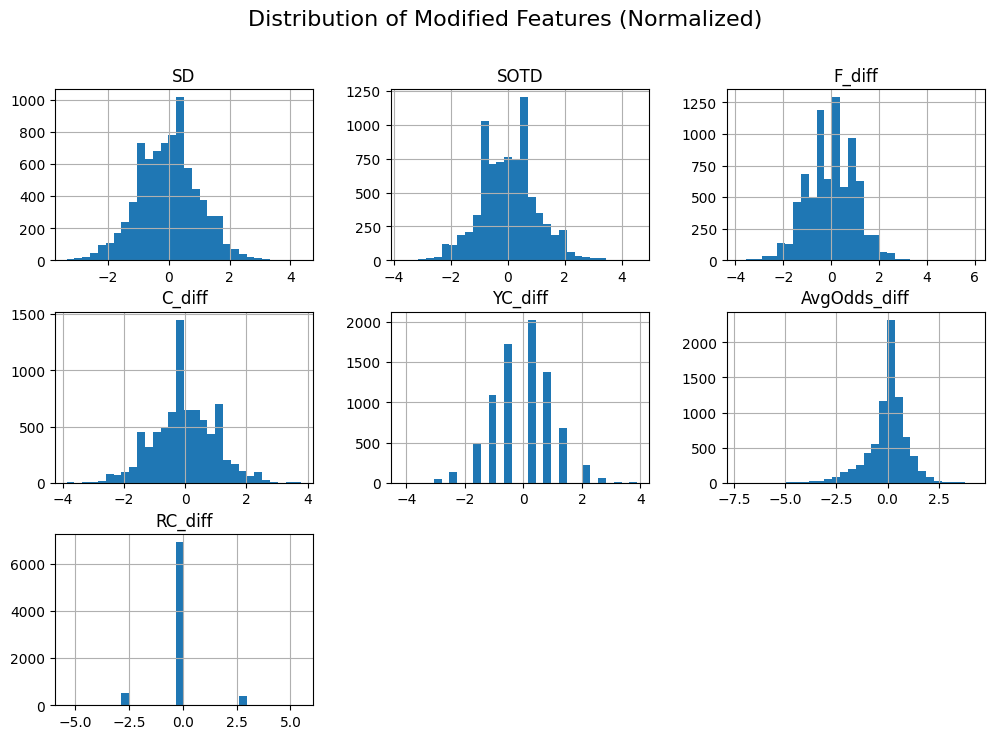

In [27]:
# --- Creating new features by calculating the difference between home and away statistics (Positive means home team have more) ---
modified_stats = pd.DataFrame({'SD': data['HS'] - data['AS'],
                            'SOTD': data['HST'] - data['AST'],
                            'F_diff': data['HF'] - data['AF'],
                            'C_diff': data['HC'] - data['AC'],
                            'YC_diff': data['HY'] - data['AY'],
                            'AvgOdds_diff': data['AvgH'] - data['AvgA'],
                            'RC_diff': data['HR'] - data['AR']
                            }) 

# --- Normalize the new features with average and standard deviation (Z-score normalization) ---
modified_stats = (modified_stats - modified_stats.mean()) / modified_stats.std()

# -- Plot as histogram to see the distribution of the new features ---
modified_stats.hist(bins=30, figsize=(12, 8))
plt.suptitle('Distribution of Modified Features (Normalized)', fontsize=16)
plt.show()

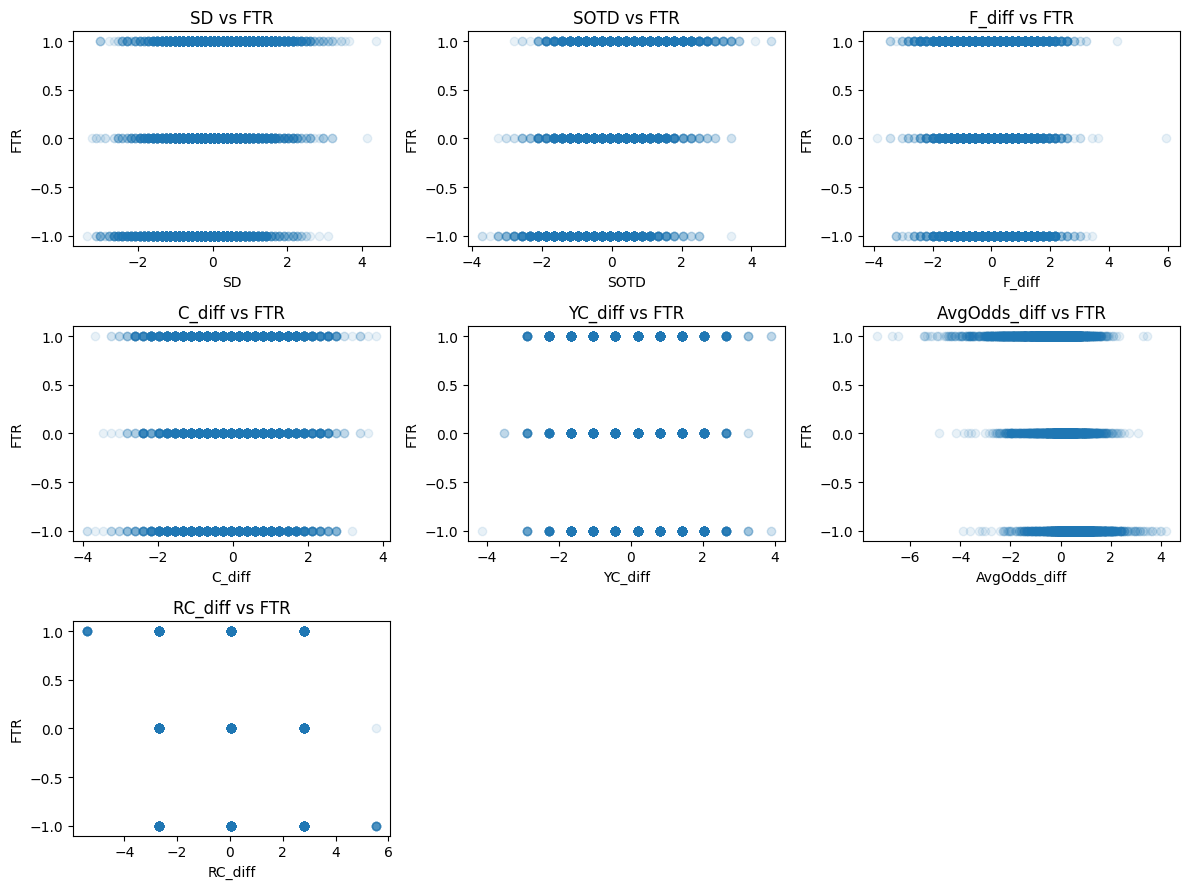

In [28]:
n_cols = 3  # number of columns in the subplot grid
n_features = len(modified_stats.columns)
n_rows = math.ceil(n_features / n_cols)

plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, column in enumerate(modified_stats.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(modified_stats[column], ground_truth, alpha=0.1)
    plt.title(f'{column} vs FTR')
    plt.xlabel(column)
    plt.ylabel('FTR')

plt.tight_layout()
plt.show()

## DBSCAN

#### Tuning the parameter $\epsilon$
Before running DBSCAN on the dataset, we try to find the best hyperparameter for $\epsilon$.

First we want to find the "border object" or "first valley" (non differentiable point). This is done by defining a function that for each point find the distance to the k-nearest neighbor. This distance is the distance to the MinPts-nearest nighbor where MinPts is set to $2d-1$ where $d$ is the number of features (Slide 22 lecture 3).

The distance measure used is the euclediean distance.

Afterwards we plot the distances in descending order.

In [29]:
# -- Calculating K nearest neighbours --

from scipy.spatial.distance import cdist

def find_k_nearest_neighbor_dist(data, minpts=None, use_tqdm=True):
    """
    Compute the distance to the k-th nearest neighbor for each point.

    Parameters:
        data (numpy array): Shape (n_samples, d_features)
        minpts (int): Number of neighbors to consider (default 2*d - 1 -- See slide 22 lecture 3)
        use_tqdm (bool): Show progress bar for large datasets

    Returns:
        distances_sorted (numpy array): k-th nearest neighbor distances sorted descending
        minpts (int): The k used
    """
    n, d = data.shape
    if minpts is None:
        minpts = 2 * d - 1

    # Compute full pairwise distance matrix (n x n)
    pairwise_dist = cdist(data, data, metric='euclidean') # Euclean distance is used

    # Set diagonal to np.inf to ignore self-distance
    np.fill_diagonal(pairwise_dist, np.inf)

    distances = np.zeros(n)

    iterator = tqdm(range(n), disable=not use_tqdm)
    for i in iterator:
        # Sort distances for this point
        sorted_dists = np.partition(pairwise_dist[i], minpts)  # faster than full sort
        distances[i] = sorted_dists[minpts]  # minpts-th nearest neighbor

    # Return distances sorted descending
    return np.sort(distances)[::-1], minpts



y, minpts = find_k_nearest_neighbor_dist(modified_stats.values)
print('Found value for minpts:', minpts)

100%|██████████| 7860/7860 [00:00<00:00, 23093.93it/s]

Found value for minpts: 13


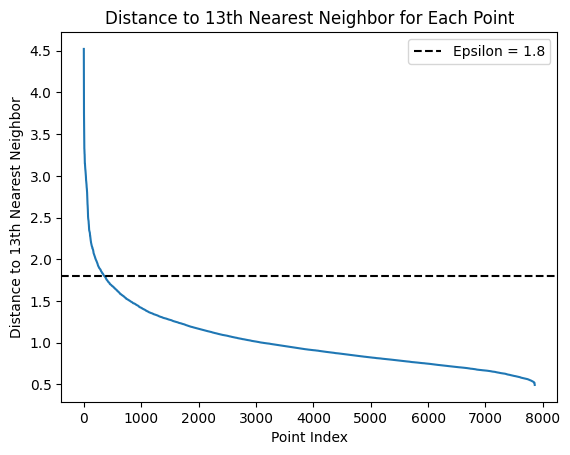

In [30]:
# -- Plotting K nearest Neighbor distances---
x = np.arange(len(y))
epsilon = 1.8
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel("Point Index")
ax.set_ylabel(f"Distance to {minpts}th Nearest Neighbor")
ax.set_title(f"Distance to {minpts}th Nearest Neighbor for Each Point")
ax.axhline(epsilon, c='k', ls='--', label=f'Epsilon = {epsilon}')
plt.legend()

As seen above, it is hard to to determine the right $\epsilon$ as there is no clear valley in the plot. This is a sign that there isn't some clearly defined clusters in the data, as the density acts continously rather than discretely.
However we choose $\epsilon = 1.8$, and continue to DBSCAN.

#### DBSCAN clustering

From sklearn we use the method DBSCAN. The two hyperparameters are set to $\epsilon = 1.8$ and $MinPts = 2d-1 = 13$.

In [31]:
dbscan = DBSCAN(eps=epsilon, min_samples=minpts)
dbscan.fit(modified_stats.values)
labels = dbscan.labels_
print("DBSCAN Cluster Labels:", np.unique(labels)) # -1 corresponds to noise points, other integers correspond to cluster labels

DBSCAN Cluster Labels: [-1  0  1  2]


As seen above we obtain three clusters (0, 1, 2) and some noise (-1).

To evaluate the clustering, we define two functions, one makes the contingency table based on the FTR ground truth, and the other evaluates the purity score.
- The contingency table tells us how many points of each ground truth the clusters contain.
- The purity measure tells us how many points in the cluster belong to the same (most prominent) ground truth.

In [32]:
def contingency_table(C, T, ignore_noise=True): 

    """
    Parameters:
        C(numpy array):       Clusters obtained by a clustering algorithm as a nx1 vector
        T(numpy array):       Ground-truth cluster assignments as a nx1 vector

    Returns:
        ctable:   a num_clusters_of_C x num_cluster_of_T matrix containing the overlaps among the different clusters
    """
    
    if ignore_noise:
        mask = (C != -1)
        C_masked = C[mask]
        indices_masked = np.where(mask)[0]
    else:
        C_masked = C
        indices_masked = np.arange(len(C))

    clusters = np.unique(C_masked)
    classes  = np.unique(T)   # include all classes, not just masked
    
    ctable = np.zeros((len(clusters), len(classes)), dtype=int)

    for i, c in enumerate(clusters):
        for j, t in enumerate(classes):
            # count overlap only for points that are not noise
            count = np.sum((C_masked == c) & (T[indices_masked] == t))
            ctable[i, j] = count

    return ctable



def purity_score(ctable):
    """
    Parameters:
        ctable (numpy array):  Contingency table of shape (num_clusters, num_classes) containing the overlaps among the different clusters
    
    Returns:
        purity(float):   a float, the purity of clustering result
    """
    
    clusters, gt_classes = ctable.shape
    purity = np.zeros(clusters)

    for i in range(clusters):
        purity[i] = np.max(ctable[i])/np.sum(ctable[i]) if np.sum(ctable[i]) > 0 else 0
    return purity



# --- Contingency table to compare the cluster labels with the ground truth ---
c_table = contingency_table(labels, ground_truth)
print("Contingency Table:\n", c_table) 

# --- Calculate the purity of the clustering ---
purity = purity_score(c_table)
print(f"Purity score of the clustering: {purity}")

Contingency Table:
 [[2083 1671 3134]
 [  73  127  322]
 [ 185   94   83]]
Purity score of the clustering: [0.45499419 0.61685824 0.51104972]


First, looking at the contingency table, the rows correspond to different clusters, while the collumns correspond to ground truth (1: Homewin, 2: draw, 3: Homeloose). Since each row in the contingency table is heavily mixed, the clustering seems to not obtain the ground truth. This can also be seen in the purity, which calculates the proportion of elements in the cluster that belong to the most frequent class. All purities is between 45 and 64 percent, meaning no cluster is pure compared to the ground truth.

If one cluster should be highlighted it would be cluster 1. It is smaller but dominated by home losses, giving it the highest purity. This suggests DBSCAN found a small region where matches with similar characteristics tend to result in home losses.

## K-Means++ clustering
Since we are comparing to a known ground truth with 3 outcomes (Home Win, Draw, Away Win) we run K-means++ clustering with $k=3$ clusters. 
For the same reason we evaluate the clustering using two external measures: Contingency table and purity.


In [33]:
k_means = KMeans(n_clusters=3).fit(modified_stats.values)
labels_kmeans = k_means.labels_
centroids = k_means.cluster_centers_
# --- making a contengincy tabele to compare the cluster labels with the ground truth ---
c_table = contingency_table(labels_kmeans, ground_truth)
print("Contingency Table:\n", c_table) 
# --- Calculate the purity of the clustering ---
purity = purity_score(c_table)
print(f"Purity score of the clustering: {purity}")

Contingency Table:
 [[ 774  635 1042]
 [ 382  576 1763]
 [1212  695  781]]
Purity score of the clustering: [0.4251326  0.64792356 0.45089286]


The clustering obtained by using K-Means is by no means better that the one obtained from using DBSCAN

## T-SNE


To investigate whether our features could reveal meaningful clusters, we applied **t-distributed Stochastic Neighbor Embedding (T-SNE)**.  

T-SNE is basically a dimensionality reduction algorithm that is useful for visualizing high-dimensional data. It works by modeling pairwise similarities between points in the high-dimensional space and trying to preserve these similarities in a lower-dimensional space. Essentially, points that are close in the original feature space should remain close in the lower dimension visualization, while distant points stay far apart.

The goal of using T-SNE here was to see if our features could form clusters and investigate properties of these clusters. This analysis serves as a useful check

In [34]:
# Fit + transform
tsne = TSNE(2, perplexity=10)
embedding = tsne.fit_transform(modified_stats.values)

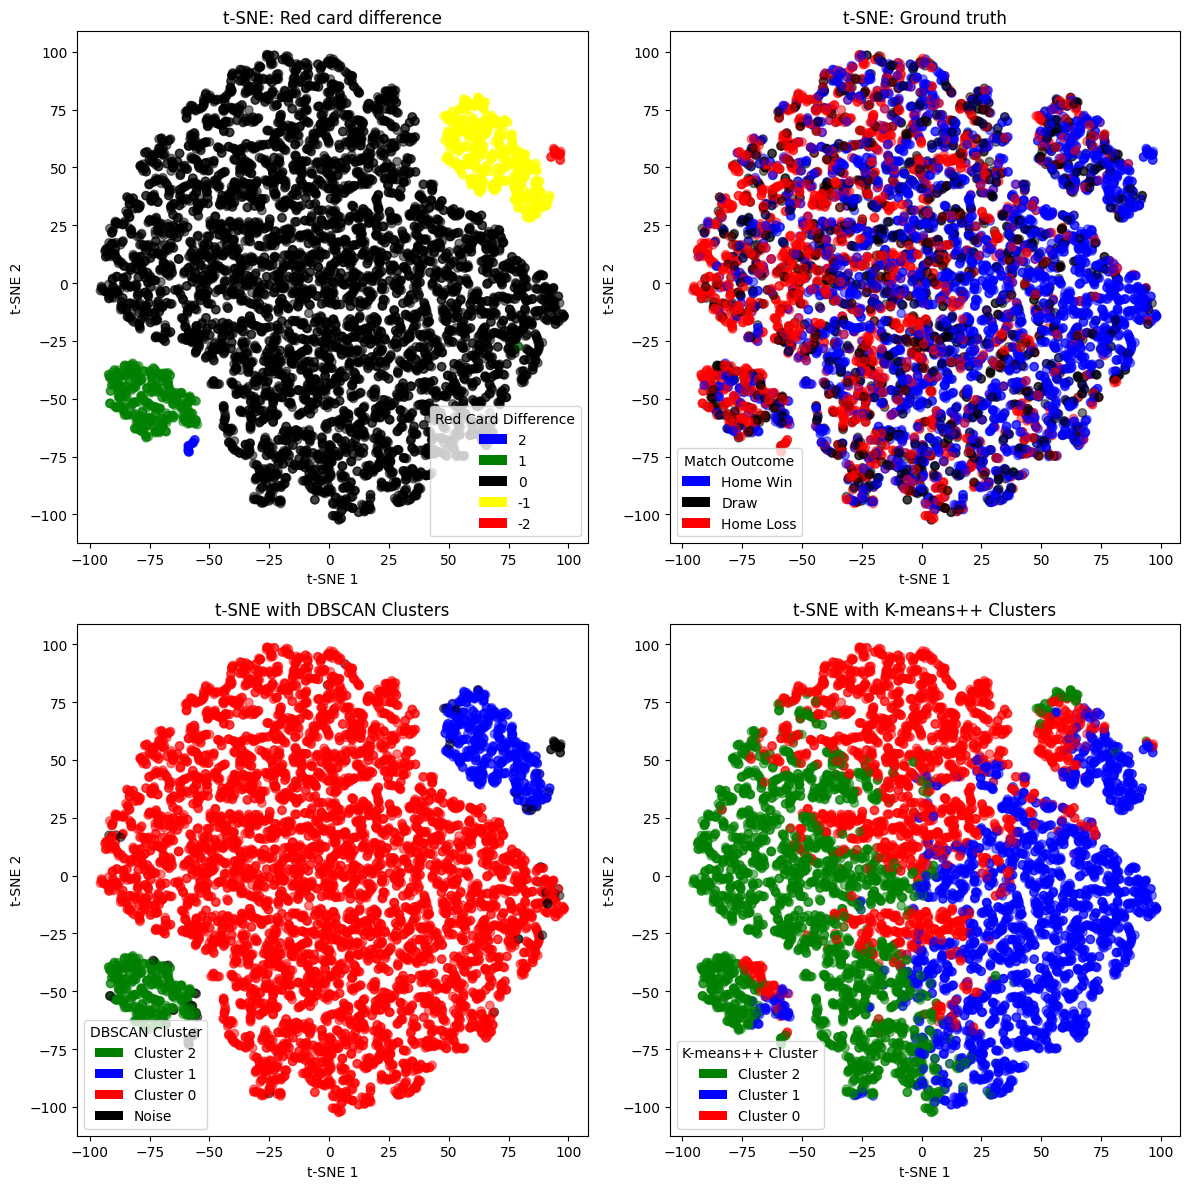

In [35]:
# --- Prepare evaluation values ---
eval_dataframe = pd.DataFrame({'RC_diff': data['HR'] - data['AR']})
evaluating_measure = eval_dataframe.values.flatten()
labels_dbscan = dbscan.labels_
labels_kmeans = k_means.labels_

# --- Color maps ---
color_map1 = {2: 'blue', 1: 'green', 0: 'black', -1: 'yellow', -2: 'red'}
color_map2 = {1: 'blue', 0: 'black', -1: 'red'}
color_map3 = {2: 'green', 1: 'blue', 0: 'red', -1: 'black'}
color_map4 = {2: 'green', 1: 'blue', 0: 'red'}

# --- Prepare colors ---
colors1 = [color_map1[int(val)] for val in evaluating_measure] 
colors2 = [color_map2[int(val)] for val in ground_truth] 
colors3 = [color_map3[int(val)] for val in labels] 
colors4 = [color_map4[int(val)] for val in labels_kmeans]

# --- Legends ---
legend_1 = {2: '2', 1: '1', 0: '0', -1: '-1', -2: '-2'}
legend_2 = {1: 'Home Win', 0: 'Draw', -1: 'Home Loss'}
legend_3 = {2: 'Cluster 2', 1: 'Cluster 1', 0: 'Cluster 0', -1: 'Noise'}
legend_4 = {2: 'Cluster 2', 1: 'Cluster 1', 0: 'Cluster 0'}

# --- Create figure ---
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax = ax.flatten()

# --- Subplot 1: Red card difference ---
ax[0].scatter(embedding[:, 0], embedding[:, 1], color=colors1, alpha=0.5)
ax[0].set_xlabel("t-SNE 1")
ax[0].set_ylabel("t-SNE 2")
ax[0].set_title("t-SNE: Red card difference")
legend_elements1 = [Patch(facecolor=color_map1[key], label=legend_1[key]) for key in legend_1]
ax[0].legend(handles=legend_elements1, title="Red Card Difference")

# --- Subplot 2: Match outcome ---
ax[1].scatter(embedding[:, 0], embedding[:, 1], color=colors2, alpha=0.5)
ax[1].set_xlabel("t-SNE 1")
ax[1].set_ylabel("t-SNE 2")
ax[1].set_title("t-SNE: Ground truth")
legend_elements2 = [Patch(facecolor=color_map2[key], label=legend_2[key]) for key in legend_2]
ax[1].legend(handles=legend_elements2, title="Match Outcome")

# --- Subplot 3: DBSCAN clusters ---
ax[2].scatter(embedding[:, 0], embedding[:, 1], color=colors3, alpha=0.5)
ax[2].set_xlabel("t-SNE 1")
ax[2].set_ylabel("t-SNE 2")
ax[2].set_title("t-SNE with DBSCAN Clusters")
legend_elements3 = [Patch(facecolor=color_map3[key], label=legend_3[key]) for key in legend_3]
ax[2].legend(handles=legend_elements3, title="DBSCAN Cluster")

# --- Subplot 4: K-means++ clusters ---
ax[3].scatter(embedding[:, 0], embedding[:, 1], color=colors4, alpha=0.5)
ax[3].set_xlabel("t-SNE 1")
ax[3].set_ylabel("t-SNE 2")
ax[3].set_title("t-SNE with K-means++ Clusters")
legend_elements4 = [Patch(facecolor=color_map4[key], label=legend_4[key]) for key in legend_4]
ax[3].legend(handles=legend_elements4, title="K-means++ Cluster")

plt.tight_layout()
plt.show()

The concern that the DBSCAN algorithm has only clustered by red card diffrence in matches can be verified by calculating a contigency table with red card diffrence as the evaluating measure. The result can be seen below from which it is evident that DBSCAN produced no meaningful clusters in terms of predicting match outcomes.

In [36]:
c_table = contingency_table(labels, evaluating_measure)
print("Contingency Table:\n", c_table)

Contingency Table:
 [[   0    0 6888    0    0]
 [   0  522    0    0    0]
 [   0    0    0  362    0]]


## Disregarding disciplinary sanctions
Therefore we decided to disregard the yellow and red card features to see if that made it possible to find useful clusters. Below, the same analysis is made again.

In [37]:
# --- Creating new features again but disregarding disciplinary actions ---
modified_stats = pd.DataFrame({'SD': data['HS'] - data['AS'],
                            'SOTD': data['HST'] - data['AST'],
                            'F_diff': data['HF'] - data['AF'],
                            'C_diff': data['HC'] - data['AC'],
                            'AvgOdds_diff': data['AvgH'] - data['AvgA']
                            }) 

# --- Normalize the new features with average and standard deviation (Z-score normalization) ---
modified_stats = (modified_stats - modified_stats.mean()) / modified_stats.std()

In [38]:
y, minpts = find_k_nearest_neighbor_dist(modified_stats.values)
print('Found value for minpts:', minpts)

100%|██████████| 7860/7860 [00:00<00:00, 17630.08it/s]

Found value for minpts: 9


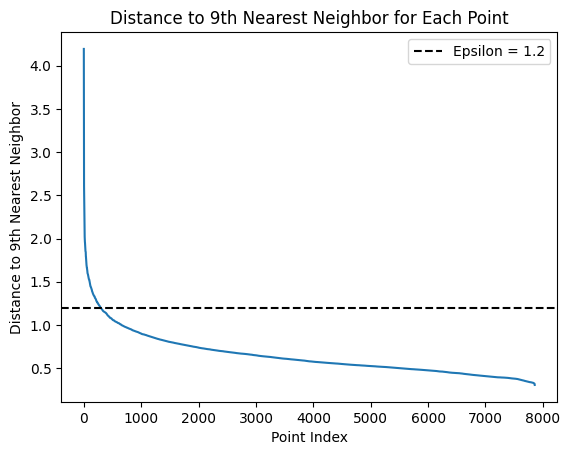

In [43]:
# -- Plotting K nearest Neighbor distances---
x = np.arange(len(y))
epsilon = 1.2
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel("Point Index")
ax.set_ylabel(f"Distance to {minpts}th Nearest Neighbor")
ax.set_title(f"Distance to {minpts}th Nearest Neighbor for Each Point")
ax.axhline(epsilon, c='k', ls='--', label=f'Epsilon = {epsilon}')
plt.legend()

## DBSCAN without displinary actions

In [40]:
dbscan = DBSCAN(eps=epsilon, min_samples=minpts)
dbscan.fit(modified_stats.values)
labels = dbscan.labels_
print("DBSCAN Cluster Labels:", np.unique(labels)) # -1 corresponds to noise points, other integers correspond to cluster labels
# --- Contingency table to compare the cluster labels with the ground truth ---
c_table = contingency_table(labels, ground_truth)
print("Contingency Table:\n", c_table) 

# --- Calculate the purity of the clustering ---
purity = purity_score(c_table)
print(f"Purity score of the clustering: {purity}")


DBSCAN Cluster Labels: [-1  0]
Contingency Table:
 [[2357 1895 3539]]
Purity score of the clustering: [0.45424207]


Only one cluster found???

## K-Means without displinary actions

In [41]:
k_means = KMeans(n_clusters=3).fit(modified_stats.values)
labels_kmeans = k_means.labels_
centroids = k_means.cluster_centers_
# --- making a contengincy tabele to compare the cluster labels with the ground truth ---
c_table = contingency_table(labels_kmeans, ground_truth)
print("Contingency Table:\n", c_table) 
# --- Calculate the purity of the clustering ---
purity = purity_score(c_table)
print(f"Purity score of the clustering: {purity}")

Contingency Table:
 [[ 186  337 1229]
 [1036  991 1753]
 [1146  578  604]]
Purity score of the clustering: [0.70148402 0.46375661 0.49226804]


Clusters still seem pretty bad.

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
